# Bring your own Hamiltonian

Everything in the previous notebooks went through a wrapper. But Mag$\nu$s's actual
interface is smaller than its wrapper list suggests: give it a **callable that returns a
Hermitian matrix**, and it will propagate it. The mixing parameters, the matter potential, the
BSM terms -- all of those are conveniences built on top of that one contract.

This notebook covers the contract itself, the one way of writing your `H_func` that is worth
real time, and what the Earth entry point quietly declares on your behalf.

In [1]:
import time
import warnings

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC))

## 1. Two contracts

**`oscprob.osc_prob(H_func, t_ini, t_fin)`** is the general one. `H_func(l)` takes a position
and returns a `(dim, dim)` Hermitian matrix. You supply everything, including the matter
potential.

**`oscprob.osc_prob_earth(H, ...)` and `osc_prob_sun(H, ...)`** are the profile-aware ones.
They know the density along the path, so they call `H(energy, l, VCC)` and hand you the
potential; you decide what to do with it. This is the interface to reach for when your new
physics lives in a *known* environment.

The dimension is read from what you return, so 2, 3, 4 and 5 flavours all work with no flag.

In [2]:
e00 = np.diag([1.0, 0.0, 0.0])          # the nu_e--nu_e slot the potential occupies

COSTHZ = -0.9
L_EARTH = earth.distance_traveled_inside_earth(COSTHZ)*gd.CONV_KM_TO_INV_EV
ENERGY = 5.0*gd.UNIT_GEV

def H_standard(energy, l, VCC):
    """Ordinary three-flavour oscillation, written out by hand."""
    return h_vac/energy + np.asarray(VCC)[..., None, None]*e00

print('P(nu_mu -> nu_mu) = %.9f'
      % oscprob.osc_prob_earth(H_standard, energy=ENERGY, costhz=COSTHZ, L=L_EARTH,
                               nu_i=gd.NUMU, nu_f=gd.NUMU))

P(nu_mu -> nu_mu) = 0.798064808


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1459: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

## 2. Write it so it accepts an array of positions

That `[..., None, None]` is the single most valuable line in this notebook.

Mag$\nu$s evaluates the Hamiltonian at many positions per slab. If your `H_func` handles an
**array** of positions in one call, it does so once per slab instead of once per point. The
indexing trick turns one potential per position into a stack of matrices, and the vacuum term
broadcasts against it for free.

Written the naive way -- `float(VCC)` and a fresh `(3,3)` -- everything still works, and
Mag$\nu$s tells you what you are paying for with a `ScalarHamiltonianWarning`.

In [3]:
def make_H(extra_ops, vectorised):
    """The same Hamiltonian, written the fast way or the slow way.

    extra_ops stands in for a genuinely expensive H_func: a table lookup, an
    interpolation, an integral.  A plain PREM density lookup is very cheap, which
    is exactly why the speed-up below grows as the Hamiltonian gets dearer."""
    def H(energy, l, VCC):
        V = np.asarray(VCC)
        for _ in range(extra_ops):
            V = V + 1.0e-30*np.sin(V*1.0e13)
        if vectorised:
            return h_vac/energy + V[..., None, None]*e00
        m = np.zeros((3, 3))
        m[0][0] = float(V)
        return h_vac/energy + m
    return H

def best_of(H, n=5):
    best = np.inf
    for _ in range(n):
        t0 = time.perf_counter()
        P = oscprob.osc_prob_earth(H, energy=ENERGY, costhz=COSTHZ, L=L_EARTH,
                                   nu_i=gd.NUMU, nu_f=gd.NUMU)
        best = min(best, time.perf_counter() - t0)
    return P, best

In [4]:
print('%-26s %10s %10s %10s %s'
      % ('H_func cost', 'scalar [s]', 'array [s]', 'speed-up', 'identical'))
print('-'*70)
for extra, label in ((0, 'plain PREM lookup'), (5, '5 extra ops/call'),
                     (50, '50 extra ops/call')):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        P_scalar, t_scalar = best_of(make_H(extra, False))
    P_array, t_array = best_of(make_H(extra, True))
    print('%-26s %10.4f %10.4f %9.2fx %s'
          % (label, t_scalar, t_array, t_scalar/t_array, P_scalar == P_array))

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1459: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

H_func cost                scalar [s]  array [s]   speed-up identical
----------------------------------------------------------------------
plain PREM lookup              0.0070     0.0024      2.93x True
5 extra ops/call               0.0083     0.0024      3.42x True


50 extra ops/call              0.0136     0.0035      3.94x True


Bit-identical output, every time -- this is a pure restructuring, not an
approximation. The gain grows with what your Hamiltonian costs, which is the point: on a bare
PREM lookup there is little to save, and on a real interpolated profile or an integral there is
a great deal. The package documentation quotes **4.6x** on a three-flavour exponential-density
profile, measured the same way.

The warning fires once per session and names the fix:

In [5]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    oscprob.osc_prob_earth(make_H(0, False), energy=ENERGY, costhz=COSTHZ,
                           L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)

for w in caught:
    if w.category is not UserWarning:
        print('%s\n' % w.category.__name__)

ScalarHamiltonianWarning

MagnusConvergenceWarning

MagnusConvergenceWarning

MagnusConvergenceWarning

MagnusConvergenceWarning



## 3. What the Earth entry point declares for you

A chord through a spherically symmetric Earth meets every radius twice, so its density profile
reads the same from either end -- it is a **palindrome**. Mag$\nu$s can then evaluate your
`H_func` on the first half of the slab chain and obtain the rest by reversal, halving the
calls.

That is geometry rather than an assumption about your input, which is why `osc_prob_earth` is
allowed to declare it (via `symmetric_over`) and a general caller is not. `osc_prob_sun` does
**not** declare it: a solar profile is monotonic, not mirror-symmetric.

The declaration is also withdrawn when it would not be true -- a request over part of a chord
rather than the whole of it is not symmetric, and is not mirrored.

It is worth what your Hamiltonian costs: 1.4--1.67x on an expensive `H_func`, and about 0.91x
on plain PREM, where halving cheap lookups does not repay the bookkeeping.
`magnus.magnus.USE_PALINDROME` disarms it globally. Notebook 24 measures this.

## 4. A worked example: a long-range force

Suppose a new $L_\mu - L_\tau$ gauge boson couples neutrinos to the electrons of the Earth.
The resulting potential is proportional to the same electron density Mag$\nu$s already hands
you -- so the whole model is one extra term, with the matrix structure of the new charge.

In [6]:
mu_tau = np.diag([0.0, 1.0, -1.0])     # the L_mu - L_tau charge

def H_long_range(energy, l, VCC, eps=0.15):
    """Standard oscillation plus a flavour-diagonal long-range potential.

    eps is the new coupling in units of the weak one, so eps*VCC is the new
    potential -- deliberately the crudest possible parametrisation, to keep the
    example about the interface rather than about the model."""
    V = np.asarray(VCC)[..., None, None]
    return h_vac/energy + V*e00 + eps*V*mu_tau

E_gev = np.logspace(-0.3, 1.5, 60)
E_scan = E_gev*gd.UNIT_GEV

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    p_std = oscprob.osc_prob_earth(H_standard, energy=E_scan, costhz=COSTHZ,
                                   L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)
    p_lrf = oscprob.osc_prob_earth(H_long_range, energy=E_scan, costhz=COSTHZ,
                                   L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)

gap = np.abs(np.asarray(p_std) - np.asarray(p_lrf))
print('max |standard - long range| = %.4f  at %.2f GeV'
      % (gap.max(), E_gev[gap.argmax()]))

max |standard - long range| = 0.9960  at 22.26 GeV


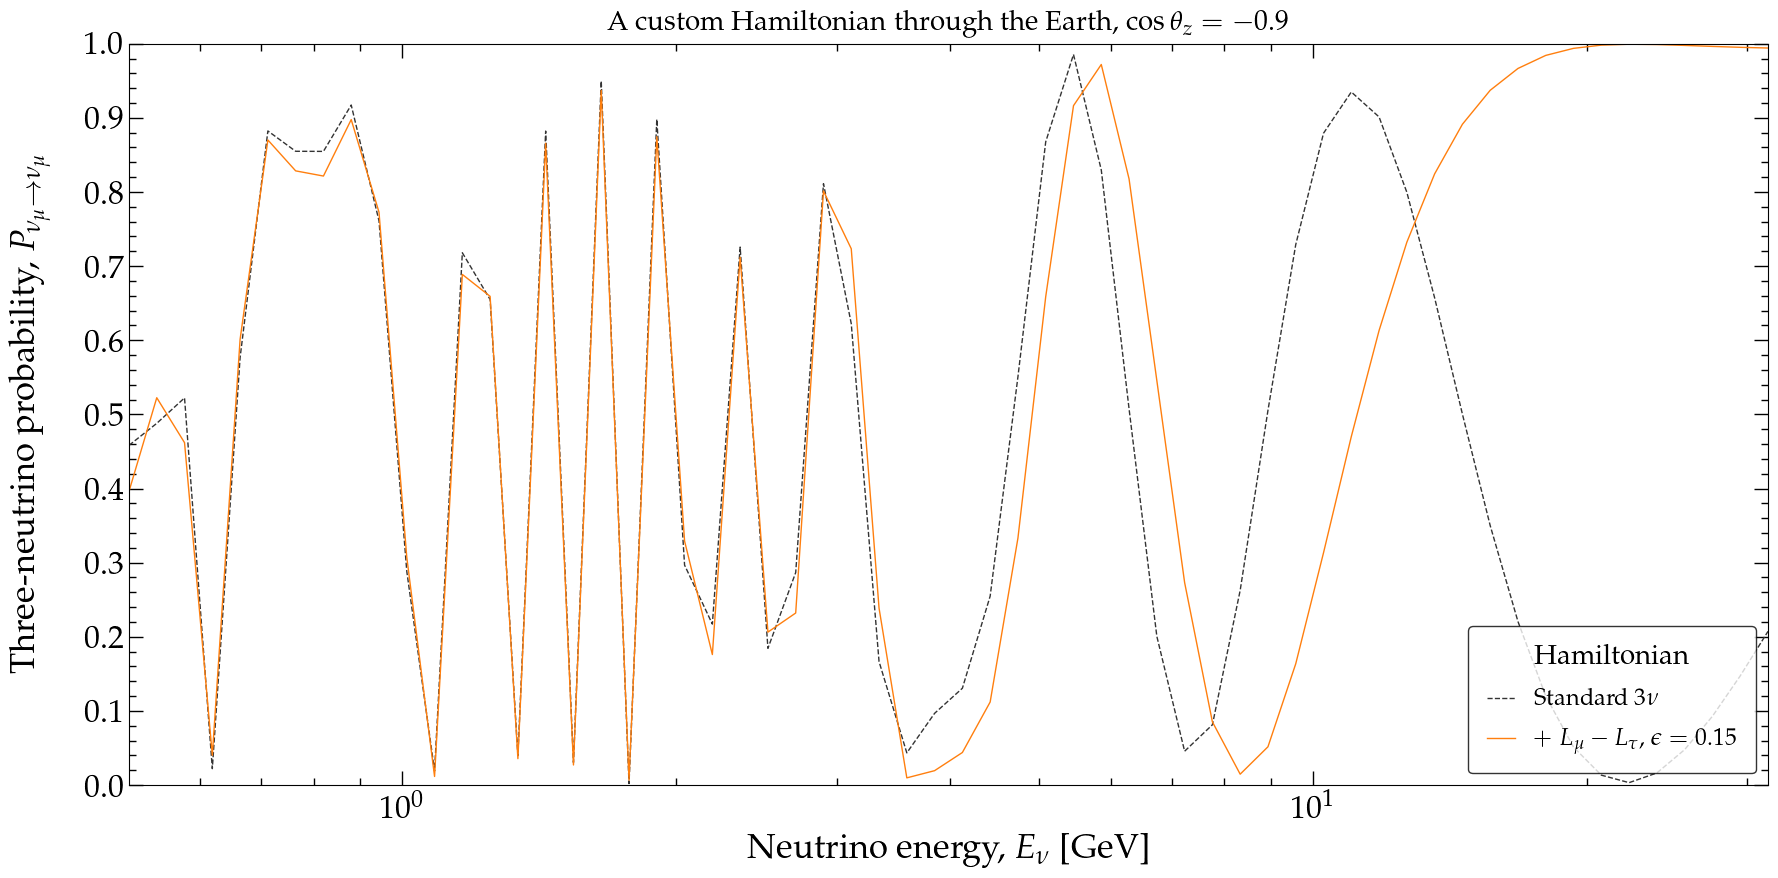

In [7]:
fig, ax = plotting.plot_probability_vs_energy(
    E_gev,
    [dict(y=np.asarray(p_std), label=r'Standard $3\nu$', color='0.2', ls='--'),
     dict(y=np.asarray(p_lrf), label=r'$+\;L_\mu - L_\tau$, $\epsilon = 0.15$',
          color='C1')],
    nu_i=gd.NUMU, nu_f=gd.NUMU, num_flavors=3,
    xlim=(E_gev[0], E_gev[-1]),
    legend_title='Hamiltonian', legend_loc='lower right',
    title=r'A custom Hamiltonian through the Earth, $\cos\theta_z = %.1f$' % COSTHZ)

## Summary -- a checklist for your own `H_func`

1. **Return a Hermitian matrix.** The dimension is inferred; 2 to 5 flavours need no flag.
2. **Accept an array of positions**, and use `np.asarray(VCC)[..., None, None]` to build the
   stack. Bit-identical results, and the gain grows with what your Hamiltonian costs.
3. **Take the matter potential from the entry point** (`osc_prob_earth`/`osc_prob_sun`) or
   from `matter.vcc_func_from_rho_func`. For antineutrinos pass `nubar=True` there and do not
   negate it again -- notebook 15.
4. **Declare discontinuities** with `t_breakpoints`. A slab straddling a jump is not fixed by
   refinement -- notebook 18.
5. **Do not declare symmetry yourself.** `osc_prob_earth` does it where geometry guarantees it.

If you want to know which engine then answered your request, and whether to believe it, that
is notebooks 21 and 22.

---

**Previous:** [Unusual density profiles](18_magnus_unusual_density_profiles.ipynb)  
**Next:** [Numerical edge cases](20_magnus_numerical_edge_cases.ipynb) --- degeneracies that return numbers, and what the nine warnings mean  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)